In [1]:
import numpy as np
import scipy.io as sio
import os
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
import random
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
#create pandas dataframe from data

In [3]:
df_sessions_m1_phase1 = {}

directory = '/home/dvoina/myproj1/pooya_data/M1_Phase1_Lf_gratings/'
files = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
files_split = [f.split('_') for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]

In [4]:
new_files = []
for i, f in enumerate(files_split):
    new_files.append([])
    new_files[i].append(int(f[0][1:]))
    new_files[i].append(int(f[1][1:]))
new_files = np.array(new_files)

In [5]:
n_sessions = len(np.unique(np.array(new_files[:, 1])))
n_sessions

12

In [6]:
list_of_stim = ["circ", "circ", "rad", "rad"]*7
list_of_snr = [1.0]*4 + [0.8]*4 + [0.65]*4 + [0.5]*4 + [0.35]*4 + [0.2]*4 + [0.05]*4
list_of_pos = ["R", "L"] * 14

In [7]:
list_of_stim = ["circ", "circ", "rad", "rad"]*7
list_of_snr = [1.0]*4 + [0.8]*4 + [0.65]*4 + [0.5]*4 + [0.35]*4 + [0.2]*4 + [0.05]*4
list_of_pos = ["R", "L"] * 14

In [8]:
def get_neuron_rows(n, filename):
    mat_contents = sio.loadmat(directory + filename)

    #print("NEURON N", n)
    total_rows = 0
    
    rows = []
    for trial in range(28):

        #print("trial", trial)
        spikes = mat_contents["Spike_mat"][0][trial]["spikes"]
        n_trials = spikes.shape[0]
        #print("n_trials", n_trials)

        #print(list_of_snr[trial], list_of_stim[trial])
        for t in range(n_trials):
            rows.append({
                "neuron_id": n,
                "spike_ts": np.array(spikes[t,:]).flatten(),
                "firing": np.array(spikes[t,:]).flatten()[500:850].sum(),
                "stim": list_of_stim[trial],
                "snr": list_of_snr[trial],
                "pos": list_of_pos[trial],
                "trial": total_rows
            })

            total_rows += 1

    #print("total_rows", total_rows)
    return rows

dict_of_neurons = {}
for session in np.unique(new_files[:, 1]):
    ind_s = np.where(new_files[:, 1] == session)[0]
    neurons = new_files[ind_s, 0]
    dict_of_neurons[str(session)] = neurons
    
    #print("neuron number", neurons, len(neurons))
    files_s = [files[i] for i in ind_s]
    #print("session", session, neurons, files_s)

    all_rows = []
    for n, filename in zip(neurons, files_s):
        all_rows.extend(get_neuron_rows(n, filename))
        #print("len all rows", len(all_rows))
        
    df_sessions_m1_phase1[str(session)] = pd.DataFrame(all_rows, columns=["neuron_id", "spike_ts", "firing", "stim", "snr", "pos", "trial"])

In [9]:
dict_of_neurons

{'1': array([1]),
 '2': array([7, 2, 5, 4, 3, 8, 6, 1]),
 '3': array([ 5,  2, 12,  9,  7, 10, 11,  1,  6,  3,  8,  4]),
 '4': array([1, 3, 2]),
 '5': array([ 3,  8,  4,  1,  6,  7, 10,  5,  2,  9]),
 '6': array([2, 1]),
 '7': array([ 5,  2,  9,  7, 10,  1, 11,  6,  3,  8,  4]),
 '8': array([1, 3, 2]),
 '9': array([3, 8, 4, 1, 6, 7, 5, 2, 9]),
 '10': array([1, 3, 5, 7, 8, 4, 6, 2]),
 '11': array([7, 8, 5, 3, 1, 2, 9, 6, 4]),
 '12': array([17, 15,  2,  4, 13,  9,  6, 11, 12,  5, 10,  7,  8,  1, 16,  3, 14])}

In [10]:
def find_tuned_neurons(df, session, snr_list=[1.0, 0.8, 0.65, 0.5, 0.35, 0.2, 0.05]):
    
    neurons = np.unique(df[str(session)].neuron_id.values)
    neurons_tuned_circ = []
    neurons_tuned_rad = []
    neurons_untuned = []
    
    for n in neurons:

        circular_firings = []
        radial_firings = []
        for SNR in snr_list:
            circular = df_sessions_m1_phase1[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == n)]
            radial = df_sessions_m1_phase1[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == n)]

            #print(len(circular.firing.values), len(radial.firing.values))
            
            circular_firings += list(circular.firing.values)
            radial_firings += list(radial.firing.values)

        stat, p_value = mannwhitneyu(circular_firings, radial_firings, alternative='two-sided')
        
        """
        if p_value<=0.05:
            if np.array(circular_firings).mean() > np.array(radial_firings).mean():
                neurons_tuned_circ.append(n)
            else:       
                neurons_tuned_rad.append(n)
        else:5
            neurons_untuned.append(n)
        """
        stat, p_value1 = mannwhitneyu(circular_firings, radial_firings, alternative='greater')
        stat, p_value2 = mannwhitneyu(radial_firings, circular_firings, alternative='greater')
        stat, p_value = mannwhitneyu(radial_firings, circular_firings, alternative='two-sided')
        print("p value", p_value, np.array(circular_firings).mean(), np.array(radial_firings).mean())
        
        if p_value1<=0.05:
                neurons_tuned_circ.append(n)
        elif p_value2<=0.05:       
                neurons_tuned_rad.append(n)
        elif (p_value1 > 0.05) and (p_value2 >0.1):
            neurons_untuned.append(n)
    return neurons_tuned_circ, neurons_tuned_rad, neurons_untuned

neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, 2, snr_list=[1])
tunings = [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned]
neurons_tuned_circ, neurons_tuned_rad, neurons_untuned

p value 0.5630515150259174 2.5 1.9230769230769231
p value 1.0 0.25 0.3076923076923077
p value 0.2647122119216704 1.25 1.8461538461538463
p value 0.011507473423882097 0.75 0.0
p value 0.8193171005150995 5.25 4.3076923076923075
p value 0.9064183894293188 2.25 1.9230769230769231
p value 0.6062378123063674 0.75 0.46153846153846156
p value 0.349830716554822 2.0 2.769230769230769


([4], [], [1, 2, 3, 5, 6, 7, 8])

In [11]:
#Q1:What is the imbalance? in toy model: 80% versus 20%

total_neuron_number = 0
total_number_tuned_circular = 0;
total_number_tuned_radial = 0;
total_number_untuned = 0

number_tuned_circular = [];
number_tuned_radial = [];
number_untuned = [];

neuron_id_tuned_circular = []
neuron_id_tuned_radial = []
neuron_id_tuned_untuned = []

percentage_of_interest_circ_vs_rad = []
percentage_of_interest_stim_vs_untuned = []

for session in range(1,n_sessions+1):
    print("session", session)
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session, snr_list=[1.0])

    print(neurons_tuned_circ)
    print(neurons_tuned_rad)
    print(neurons_untuned)
    total_number_tuned_circular += len(neurons_tuned_circ)
    total_number_tuned_radial += len(neurons_tuned_rad)
    total_number_untuned += len(neurons_untuned)

    number_tuned_circular.append(len(neurons_tuned_circ))
    number_tuned_radial.append(len(neurons_tuned_rad))
    number_untuned.append(len(neurons_untuned))

    neurons_tuned_circ = np.array(neurons_tuned_circ) + total_neuron_number
    neurons_tuned_rad = np.array(neurons_tuned_rad) + total_neuron_number
    neurons_untuned = np.array(neurons_untuned) + total_neuron_number

    neuron_id_tuned_circular += list(neurons_tuned_circ)
    neuron_id_tuned_radial += list(neurons_tuned_rad)
    neuron_id_tuned_untuned += list(neurons_untuned)
    
    total_neuron_number += len(neurons_tuned_circ) + len(neurons_tuned_rad) + len(neurons_untuned)
    
    if len(neurons_tuned_circ) + len(neurons_tuned_rad) != 0:
        percentage_of_interest_circ_vs_rad.append(len(neurons_tuned_circ)/(len(neurons_tuned_circ) + len(neurons_tuned_rad)))
    else:
        percentage_of_interest_circ_vs_rad.append(0)
    percentage_of_interest_stim_vs_untuned.append((len(neurons_tuned_circ) + len(neurons_tuned_rad))/(len(neurons_tuned_circ) + len(neurons_tuned_rad) + len(number_untuned)))
    

session 1
p value 0.0021481559110763525 2.3181818181818183 0.7142857142857143
[1]
[]
[]
session 2
p value 0.5630515150259174 2.5 1.9230769230769231
p value 1.0 0.25 0.3076923076923077
p value 0.2647122119216704 1.25 1.8461538461538463
p value 0.011507473423882097 0.75 0.0
p value 0.8193171005150995 5.25 4.3076923076923075
p value 0.9064183894293188 2.25 1.9230769230769231
p value 0.6062378123063674 0.75 0.46153846153846156
p value 0.349830716554822 2.0 2.769230769230769
[4]
[]
[1, 2, 3, 5, 6, 7, 8]
session 3
p value 0.23196687206193245 0.8214285714285714 0.4
p value 0.41591178402801987 0.2857142857142857 0.3333333333333333
p value 0.006507383583581102 2.392857142857143 1.0
p value 0.07498381336189554 1.8571428571428572 1.1333333333333333
p value 0.019778140596591276 0.9642857142857143 0.26666666666666666
p value 0.10794170033538601 1.9285714285714286 3.2666666666666666
p value 0.17232228566035523 1.6071428571428572 2.7333333333333334
p value 0.09160882682142464 1.5357142857142858 0.733

In [12]:
#neuron_id_tuned_circular_just1 = neuron_id_tuned_circular.copy()
#neuron_id_tuned_radial_just1 = neuron_id_tuned_radial.copy()

print("total neuron number: ", total_neuron_number)
print(neuron_id_tuned_circular, neuron_id_tuned_radial, neuron_id_tuned_untuned)
print(len(neuron_id_tuned_circular), len(neuron_id_tuned_radial), len(neuron_id_tuned_untuned))
#print(neuron_id_tuned_circular_just1, neuron_id_tuned_radial_just1)

total neuron number:  88
[1, 5, 12, 13, 14, 17, 33, 34, 35, 36, 39, 41, 42, 43, 44, 51, 52, 53, 54, 55, 56, 57, 63, 64, 65, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 79, 81, 85, 86, 87, 88] [21, 19, 24, 25, 28, 29, 49, 58] [2, 3, 4, 6, 7, 8, 9, 10, 11, 18, 19, 20, 21, 22, 23, 26, 27, 30, 31, 33, 37, 38, 40, 45, 46, 47, 48, 50, 60, 61, 62, 63, 66, 67, 78, 80, 82, 83, 84]
41 8 39


In [13]:
print(total_number_tuned_circular, total_number_tuned_radial, total_number_untuned)
print(total_number_tuned_circular/(total_number_tuned_circular + total_number_tuned_radial))
print((total_number_tuned_circular + total_number_tuned_radial)/(total_number_tuned_circular + total_number_tuned_radial + total_number_untuned))

41 8 39
0.8367346938775511
0.5568181818181818


Text(0, 0.5, 'percentage tuned')

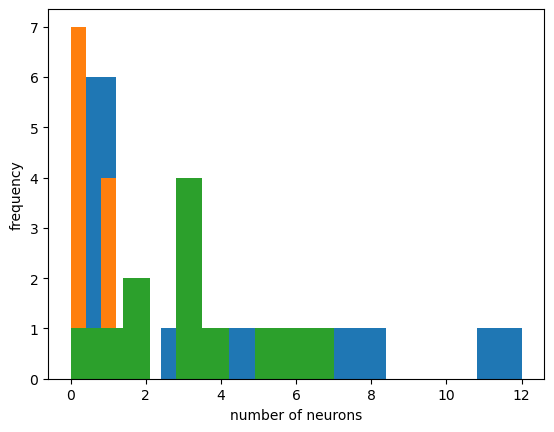

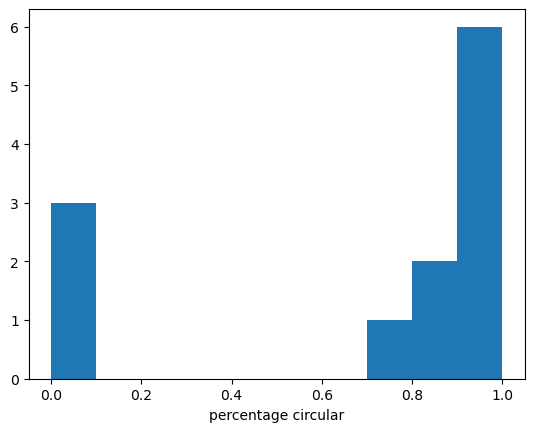

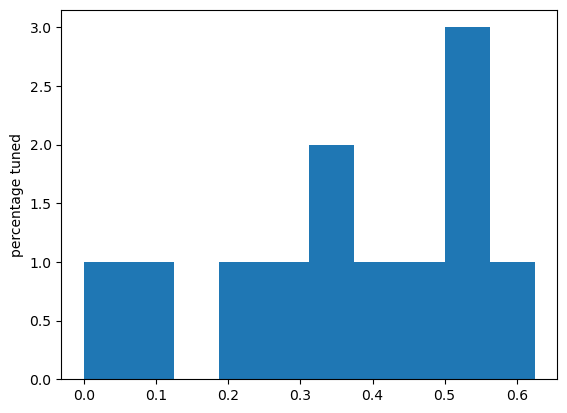

In [14]:
plt.hist(number_tuned_circular)
plt.hist(number_tuned_radial)
plt.hist(number_untuned)
plt.xlabel("number of neurons")
plt.ylabel("frequency")

plt.figure()
plt.hist(percentage_of_interest_circ_vs_rad)
plt.xlabel("percentage circular")

plt.figure()
plt.hist(percentage_of_interest_stim_vs_untuned)
plt.ylabel("percentage tuned")

In [15]:
percentage_of_interest_circ_vs_rad

[1.0, 1.0, 0.8, 0.0, 0.0, 0, 1.0, 1.0, 0.8333333333333334, 0.75, 1.0, 1.0]

In [16]:
#Conclusion: 80% of cells tuned for circular is a good choice but this is for SNR=1.0
# for lower SNR, there are sometimes fewer cells tuned for circular (see e.g., SNR=0.35)

#Possible choice 50+% cells tuned

#Important observation: are "cells tuned for circular" counted at SNR=1.0 (or low noise anyway)??

In [17]:
#create matrix of firing rate for neurons tuned to circular, radial stimuli

In [18]:
def plot(df, session, tunings, SNR):

    [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned] = tunings

    matrix_of_firing_circular = []
    matrix_of_firing_radial = []
    mean_matrix_firing_circular = []
    mean_matrix_firing_radial = []
    for nc in neurons_tuned_circ:
        #df_partial = df[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nc)]
        df_partial = df[str(session)][(df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nc)]
        matrix_of_firing_circular += list(df_partial.firing.values)
        mean_matrix_firing_circular.append(np.array(df_partial.firing.values).mean())
        
    for nr in neurons_tuned_rad:
        #df_partial = df[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nr)]
        df_partial = df[str(session)][(df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nr)]
        matrix_of_firing_radial += list(df_partial.firing.values)
        mean_matrix_firing_radial.append(np.array(df_partial.firing.values).mean())
        
    """
    try:
        matrix_of_firing_circular = np.stack(matrix_of_firing_circular)
        print("shape1", matrix_of_firing_circular.shape)
    except ValueError:
        print("empty circular (rare)")
    try:
        matrix_of_firing_radial = np.stack(matrix_of_firing_radial)
        print("shape2", matrix_of_firing_radial.shape)
    except ValueError:
        print("empty radial")
    """   

    """
    plt.figure()
    plt.plot(matrix_of_firing_circular.mean(1), "*")
    plt.plot(matrix_of_firing_radial.mean(1), "*")
    plt.xlabel("neuron index")
    plt.ylabel("avg firing")
    """

    return matrix_of_firing_circular, matrix_of_firing_radial, mean_matrix_firing_circular, mean_matrix_firing_radial


M_firing_radial = []
M_firing_circular = []
M_firing_mean_radial = []
M_firing_mean_circular = []
for session in range(1,n_sessions+1):
    
    print("session", session)
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session, snr_list=[1.0])
    tunings = [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned]
    print("number of neurons_tuned_rad", len(neurons_tuned_rad))
    print("number of neurons_tuned_circ", len(neurons_tuned_circ))
    
    #print("tunings", tunings)
    matrix_of_firing_circular, matrix_of_firing_radial, mean_matrix_firing_circular, mean_matrix_firing_radial = plot(df_sessions_m1_phase1, session, tunings, 1.0)

    M_firing_circular += matrix_of_firing_circular
    M_firing_radial += matrix_of_firing_radial
    M_firing_mean_circular += mean_matrix_firing_circular
    M_firing_mean_radial += mean_matrix_firing_radial
    
print(len(M_firing_circular), len(M_firing_radial))
print("mean firing rate, circular and radial: ", np.array(M_firing_circular).mean(), np.array(M_firing_radial).mean())
print("mean firing rate, circular and radial v2: ", np.array(M_firing_mean_circular).mean(), np.array(M_firing_mean_radial).mean())

session 1
p value 0.0021481559110763525 2.3181818181818183 0.7142857142857143
number of neurons_tuned_rad 0
number of neurons_tuned_circ 1
session 2
p value 0.5630515150259174 2.5 1.9230769230769231
p value 1.0 0.25 0.3076923076923077
p value 0.2647122119216704 1.25 1.8461538461538463
p value 0.011507473423882097 0.75 0.0
p value 0.8193171005150995 5.25 4.3076923076923075
p value 0.9064183894293188 2.25 1.9230769230769231
p value 0.6062378123063674 0.75 0.46153846153846156
p value 0.349830716554822 2.0 2.769230769230769
number of neurons_tuned_rad 0
number of neurons_tuned_circ 1
session 3
p value 0.23196687206193245 0.8214285714285714 0.4
p value 0.41591178402801987 0.2857142857142857 0.3333333333333333
p value 0.006507383583581102 2.392857142857143 1.0
p value 0.07498381336189554 1.8571428571428572 1.1333333333333333
p value 0.019778140596591276 0.9642857142857143 0.26666666666666666
p value 0.10794170033538601 1.9285714285714286 3.2666666666666666
p value 0.17232228566035523 1.60714

(array([2., 1., 1., 0., 0., 0., 2., 0., 0., 2.]),
 array([1.27906977, 1.69589963, 2.1127295 , 2.52955936, 2.94638923,
        3.36321909, 3.78004896, 4.19687882, 4.61370869, 5.03053856,
        5.44736842]),
 <BarContainer object of 10 artists>)

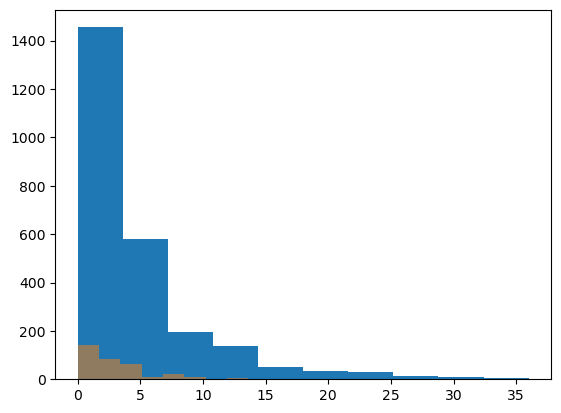

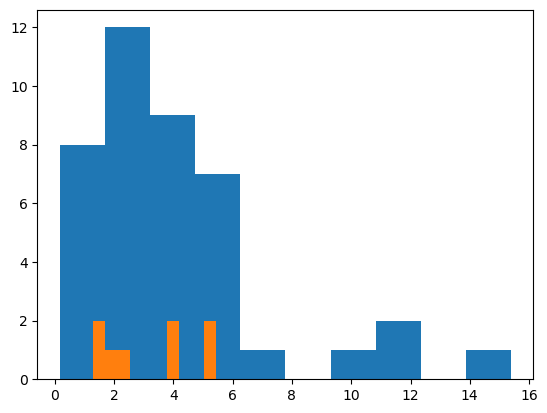

In [19]:
_ = plt.hist(np.array(M_firing_circular))
_ = plt.hist(np.array(M_firing_radial), alpha=0.5)

plt.figure()
plt.hist(M_firing_mean_circular)
plt.hist(M_firing_mean_radial)

In [20]:
#Q2: what is the level of firing rate of: (a) neurons tuned to circ firing for circ; (b) neurons tuned to circ firing for rad; 
# (c) neurons tuned to rad firing for circ; (d) neurons tuned to rad firing for rad.

In [21]:
def plot(df, session, tunings, SNR):

    [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned] = tunings

    matrix_of_tuned_circ_to_stim_circ = []
    matrix_of_tuned_circ_to_stim_rad = []
    mean_matrix_tuned_circ_to_stim_circ = []
    mean_matrix_tuned_circ_to_stim_rad = []
    matrix_of_tuned_rad_to_stim_rad = []
    matrix_of_tuned_rad_to_stim_circ = []
    mean_matrix_tuned_rad_to_stim_circ = []
    mean_matrix_tuned_rad_to_stim_rad = []
    for nc in neurons_tuned_circ:
        df_partial = df[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nc)]
        matrix_of_tuned_circ_to_stim_circ += list(df_partial.firing.values)
        mean_matrix_tuned_circ_to_stim_circ.append(np.array(df_partial.firing.values).mean())

        df_partial = df[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nc)]
        matrix_of_tuned_circ_to_stim_rad += list(df_partial.firing.values)
        mean_matrix_tuned_circ_to_stim_rad.append(np.array(df_partial.firing.values).mean())
        
    for nr in neurons_tuned_rad:
        df_partial = df[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nr)]
        matrix_of_tuned_rad_to_stim_rad += list(df_partial.firing.values)
        mean_matrix_tuned_rad_to_stim_rad.append(np.array(df_partial.firing.values).mean())
        
        df_partial = df[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nr)]
        matrix_of_tuned_rad_to_stim_circ += list(df_partial.firing.values)
        mean_matrix_tuned_rad_to_stim_circ.append(np.array(df_partial.firing.values).mean())
        
    """
    try:
        matrix_of_firing_circular = np.stack(matrix_of_firing_circular)
        print("shape1", matrix_of_firing_circular.shape)
    except ValueError:
        print("empty circular (rare)")
    try:
        matrix_of_firing_radial = np.stack(matrix_of_firing_radial)
        print("shape2", matrix_of_firing_radial.shape)
    except ValueError:
        print("empty radial")
    """   

    """
    plt.figure()
    plt.plot(matrix_of_firing_circular.mean(1), "*")
    plt.plot(matrix_of_firing_radial.mean(1), "*")
    plt.xlabel("neuron index")
    plt.ylabel("avg firing")
    """

    return matrix_of_tuned_circ_to_stim_circ, matrix_of_tuned_circ_to_stim_rad, matrix_of_tuned_rad_to_stim_rad, matrix_of_tuned_rad_to_stim_circ, mean_matrix_tuned_circ_to_stim_circ, mean_matrix_tuned_circ_to_stim_rad, mean_matrix_tuned_rad_to_stim_rad, mean_matrix_tuned_rad_to_stim_circ 
    

tuned_circ_to_stim_circ = []
tuned_circ_to_stim_rad = []
tuned_rad_to_stim_rad = []
tuned_rad_to_stim_circ = []
mean_tuned_circ_to_stim_circ = []
mean_tuned_circ_to_stim_rad = []
mean_tuned_rad_to_stim_rad = []
mean_tuned_rad_to_stim_circ = []
for session in range(1,n_sessions+1):
    
    print("session", session)
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session, snr_list=[1.0])
    tunings = [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned]
    #print("tunings", tunings)
    results = plot(df_sessions_m1_phase1, session, tunings, 1.0)

    tuned_circ_to_stim_circ += results[0]
    tuned_circ_to_stim_rad += results[1]
    tuned_rad_to_stim_rad += results[2]
    tuned_rad_to_stim_circ += results[3]
    mean_tuned_circ_to_stim_circ += results[4]
    mean_tuned_circ_to_stim_rad += results[5]
    mean_tuned_rad_to_stim_rad += results[6]
    mean_tuned_rad_to_stim_circ += results[7]

session 1
p value 0.0021481559110763525 2.3181818181818183 0.7142857142857143
session 2
p value 0.5630515150259174 2.5 1.9230769230769231
p value 1.0 0.25 0.3076923076923077
p value 0.2647122119216704 1.25 1.8461538461538463
p value 0.011507473423882097 0.75 0.0
p value 0.8193171005150995 5.25 4.3076923076923075
p value 0.9064183894293188 2.25 1.9230769230769231
p value 0.6062378123063674 0.75 0.46153846153846156
p value 0.349830716554822 2.0 2.769230769230769
session 3
p value 0.23196687206193245 0.8214285714285714 0.4
p value 0.41591178402801987 0.2857142857142857 0.3333333333333333
p value 0.006507383583581102 2.392857142857143 1.0
p value 0.07498381336189554 1.8571428571428572 1.1333333333333333
p value 0.019778140596591276 0.9642857142857143 0.26666666666666666
p value 0.10794170033538601 1.9285714285714286 3.2666666666666666
p value 0.17232228566035523 1.6071428571428572 2.7333333333333334
p value 0.09160882682142464 1.5357142857142858 0.7333333333333333
p value 0.135003267894620

5.299720113006377 1.9725295511595669 4.222564102564102 2.4811530381383324
5.919660352710647 2.146067415730337 4.140845070422535 2.2216748768472905


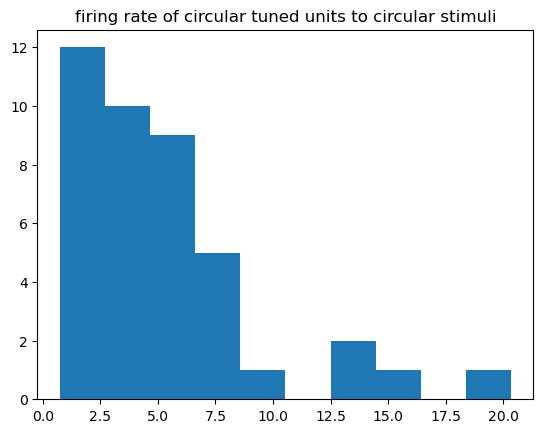

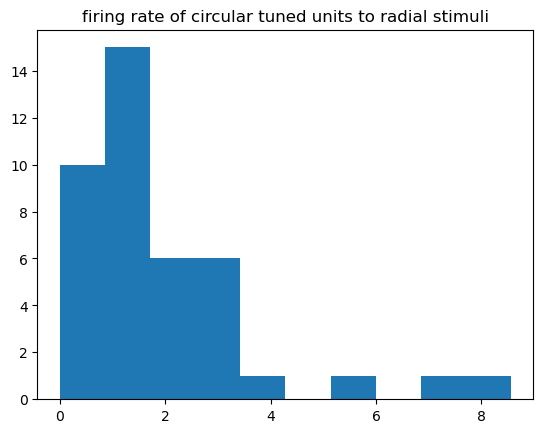

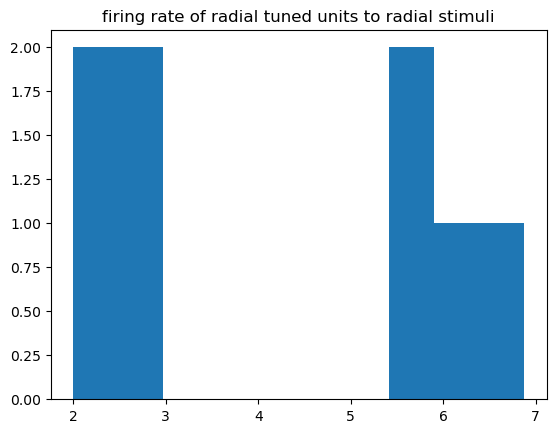

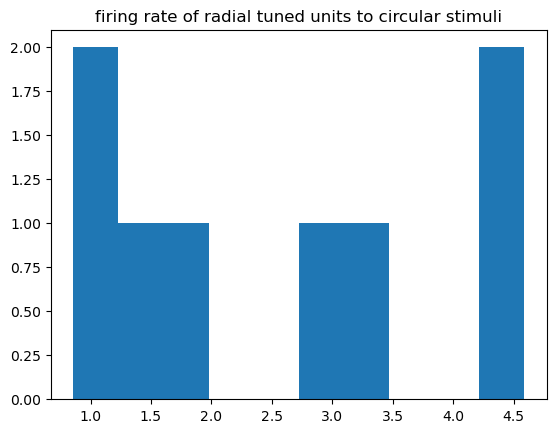

In [22]:
plt.figure()
plt.hist(mean_tuned_circ_to_stim_circ)
plt.title("firing rate of circular tuned units to circular stimuli")

plt.figure()
plt.hist(mean_tuned_circ_to_stim_rad)
plt.title("firing rate of circular tuned units to radial stimuli")

plt.figure()
plt.hist(mean_tuned_rad_to_stim_rad)
plt.title("firing rate of radial tuned units to radial stimuli")

plt.figure()
plt.hist(mean_tuned_rad_to_stim_circ)
plt.title("firing rate of radial tuned units to circular stimuli")

print(np.array(mean_tuned_circ_to_stim_circ).mean(), np.array(mean_tuned_circ_to_stim_rad).mean(), np.array(mean_tuned_rad_to_stim_rad).mean(), np.array(mean_tuned_rad_to_stim_circ).mean())

print(np.array(tuned_circ_to_stim_circ).mean(), np.array(tuned_circ_to_stim_rad).mean(), np.array(tuned_rad_to_stim_rad).mean(), np.array(tuned_rad_to_stim_circ).mean())


5.919660352710647 2.146067415730337 4.140845070422535 2.2216748768472905


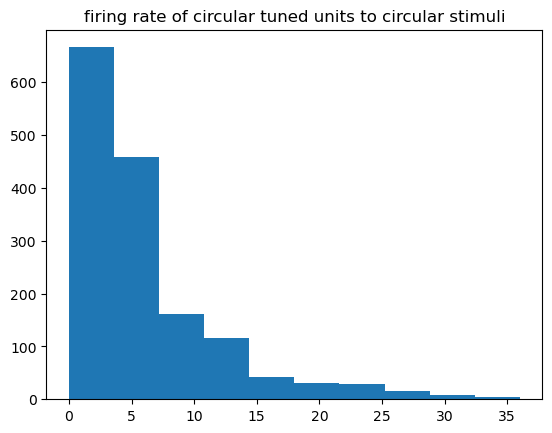

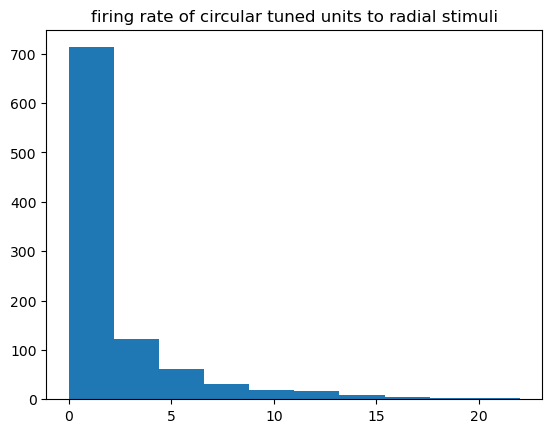

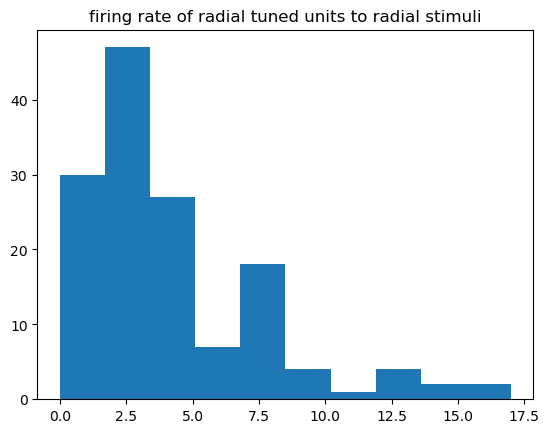

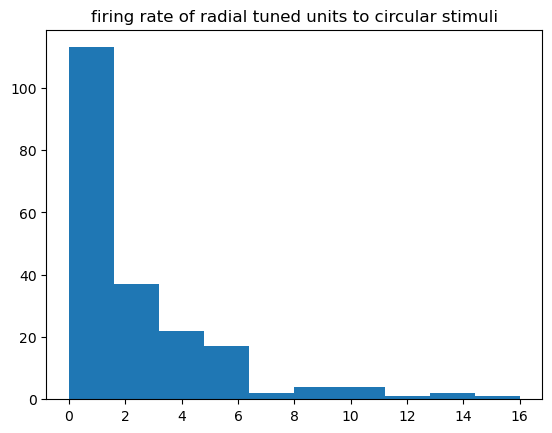

In [23]:
plt.figure()
plt.hist(tuned_circ_to_stim_circ)
plt.title("firing rate of circular tuned units to circular stimuli")

plt.figure()
plt.hist(tuned_circ_to_stim_rad)
plt.title("firing rate of circular tuned units to radial stimuli")

plt.figure()
plt.hist(tuned_rad_to_stim_rad)
plt.title("firing rate of radial tuned units to radial stimuli")

plt.figure()
plt.hist(tuned_rad_to_stim_circ)
plt.title("firing rate of radial tuned units to circular stimuli")

print(np.array(tuned_circ_to_stim_circ).mean(), np.array(tuned_circ_to_stim_rad).mean(), np.array(tuned_rad_to_stim_rad).mean(), np.array(tuned_rad_to_stim_circ).mean())


In [24]:
np.array(tuned_circ_to_stim_circ + tuned_circ_to_stim_rad).mean(), np.array(tuned_rad_to_stim_circ + tuned_rad_to_stim_rad).mean()


(4.447808764940239, 3.0115942028985505)

In [25]:
#Conclusion: circular: 6/2; radial: 4/2 or 4/3  (neurons tuned to radial firing for circular may have higher firing rates than neurons 
# tuned to circular firing for radial)

In [26]:
tuned_circ_to_stim_circ = np.array(tuned_circ_to_stim_circ)
tuned_circ_to_stim_rad = np.array(tuned_circ_to_stim_rad)
tuned_rad_to_stim_circ = np.array(tuned_rad_to_stim_circ)
tuned_rad_to_stim_rad = np.array(tuned_rad_to_stim_rad)

In [27]:
#Q3: What distribution can I fit for the firing rates of these neurons?

p-value: 0.0


/home/dvoina/anaconda3/envs/lightly_env/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:6927: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/home/dvoina/anaconda3/envs/lightly_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_3581419/1840130122.py:8: RuntimeWarning: divide by zero encountered in log
  stats.probplot(np.log(tuned_circ_to_stim_circ), dist="norm", plot=plt)
/home/dvoina/anaconda3/envs/lightly_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


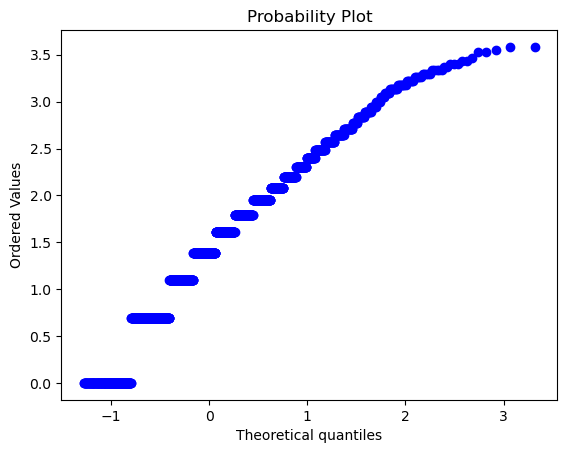

In [28]:
shape, loc, scale = stats.lognorm.fit(tuned_circ_to_stim_circ)

# KS test
stat, p_value = stats.kstest(tuned_circ_to_stim_circ, 'lognorm', args=(shape, loc, scale))
print(f"p-value: {p_value}")  # p > 0.05 → can't reject log-normal

# Q-Q plot on log-transformed data
stats.probplot(np.log(tuned_circ_to_stim_circ), dist="norm", plot=plt)
plt.show()

In [29]:
tuned_circ_to_stim_circ.mean(), tuned_circ_to_stim_circ.var()

(5.919660352710647, 36.02163175923149)

In [30]:
snr_choice = 1.0

print("FANO FACTORS for circular neurons responding to circular stimuli")
for session in range(1,n_sessions):
    
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session)

    for n in neurons_tuned_circ:
        df = df_sessions_m1_phase1[str(session)][(df_sessions_m1_phase1[str(session)].stim == 'circ') & (df_sessions_m1_phase1[str(session)].snr == snr_choice) & (df_sessions_m1_phase1[str(session)].neuron_id == n)]
        print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )

print("--------")
print("FANO FACTORS for circular neurons responding to radial stimuli")
for session in range(1,n_sessions):
    
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session)

    for n in neurons_tuned_circ:
        df = df_sessions_m1_phase1[str(session)][(df_sessions_m1_phase1[str(session)].stim == 'rad') & (df_sessions_m1_phase1[str(session)].snr == snr_choice) & (df_sessions_m1_phase1[str(session)].neuron_id == n)]
        print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )

print("--------")
print("FANO FACTORS for radial neurons responding to radial stimuli")
for session in range(1,n_sessions):

    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session)

    for n in neurons_tuned_rad:
        df = df_sessions_m1_phase1[str(session)][(df_sessions_m1_phase1[str(session)].stim == 'rad') & (df_sessions_m1_phase1[str(session)].snr == snr_choice) & (df_sessions_m1_phase1[str(session)].neuron_id == n)]
        print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )

print("--------")
print("FANO FACTORS for radial neurons responding to circular stimuli")
for session in range(1,n_sessions):

    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session)

    for n in neurons_tuned_rad:
        df = df_sessions_m1_phase1[str(session)][(df_sessions_m1_phase1[str(session)].stim == 'circ') & (df_sessions_m1_phase1[str(session)].snr == snr_choice) & (df_sessions_m1_phase1[str(session)].neuron_id == n)]
        print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )


FANO FACTORS for circular neurons responding to circular stimuli
p value 3.68285122933523e-05 2.0869565217391304 1.2171052631578947
session:  1 neuron:  1 number of trials:  22 fano factors:  1.1524064171122994
p value 0.2967407187868122 3.5384615384615383 3.0952380952380953
p value 0.3197412748112515 0.36538461538461536 0.25396825396825395
p value 0.6589714510639153 2.2884615384615383 2.015873015873016
p value 0.00220315027221794 0.9230769230769231 0.4126984126984127
p value 0.06097281085033495 6.365384615384615 4.761904761904762
p value 0.6455807405675663 2.9423076923076925 2.9047619047619047
p value 0.13959249280662295 0.6923076923076923 0.49206349206349204
p value 0.7040723944481614 3.0384615384615383 2.8412698412698414
session:  2 neuron:  4 number of trials:  4 fano factors:  0.9166666666666666
session:  2 neuron:  5 number of trials:  4 fano factors:  1.5595238095238095
p value 0.12093534585322652 0.6042780748663101 0.43956043956043955
p value 0.6822247930840197 0.31016042780748

/tmp/ipykernel_3581419/1741859078.py:20: RuntimeWarning: invalid value encountered in scalar divide
  print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )


p value 0.21084557018239136 1.8556149732620322 2.159340659340659
p value 0.9268418110683291 1.085561497326203 1.1758241758241759
p value 0.8722663214384041 1.13903743315508 1.0054945054945055
p value 0.0002234807283674141 3.213903743315508 2.489010989010989
p value 0.012476132152347864 0.8877005347593583 0.554945054945055
p value 0.7071020943725355 1.6203208556149733 0.978021978021978
p value 0.0031657903371041275 0.8449197860962567 1.1978021978021978
session:  3 neuron:  3 number of trials:  15 fano factors:  0.8
session:  3 neuron:  4 number of trials:  15 fano factors:  1.7490196078431373
session:  3 neuron:  5 number of trials:  15 fano factors:  0.7333333333333335
session:  3 neuron:  9 number of trials:  15 fano factors:  0.8761904761904763
session:  3 neuron:  10 number of trials:  15 fano factors:  1.1333333333333337
p value 0.212661010857365 4.524064171122995 5.0
p value 0.21358825706477558 11.213903743315509 10.248554913294798
p value 0.2504174515498132 9.994652406417112 8.60

In [32]:
#Conclusion: there are some neurons with Poisson distribution (when Fano factor ~1) and some neurons with negative binomial distribution
# (when Fano factor > 1). This is kind of confusing.

In [33]:
#prepare dataset on which to do Oja
#there are 93 neurons. For each one, FIX one stimulus and one SNR

In [34]:
df_all_sessions_m1_phase1 = pd.DataFrame([], columns=["neuron_id", "spike_ts", "firing", "stim", "snr", "trial"])
session_n = pd.DataFrame([], columns=["session"])

total_neurons = 0
for session in range(1,n_sessions+1):
    df_sessions_m1_phase1[str(session)].loc[:, 'neuron_id'] = df_sessions_m1_phase1[str(session)].neuron_id.copy() + total_neurons
    total_neurons += len(np.unique(np.array(df_sessions_m1_phase1[str(session)].neuron_id)))
    
    df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, df_sessions_m1_phase1[str(session)]], axis=0)
    session_n = pd.concat([session_n, pd.DataFrame([session]*len(df_sessions_m1_phase1[str(session)].neuron_id.values), columns=["session"])], axis=0)

df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, session_n], axis=1)

/tmp/ipykernel_150068/1970157889.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, df_sessions_m1_phase1[str(session)]], axis=0)


In [35]:
n_neurons = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == "circ") & (df_all_sessions_m1_phase1.snr == 1.0)].neuron_id.unique())
list_of_neurons = df_all_sessions_m1_phase1.neuron_id.unique()
n_trials = 1000
 
list_of_stim = ["circ", "rad"]
list_of_stim = list_of_stim * (n_trials//len(list_of_stim))
snr_choice = 1

In [ ]:
X_train = np.zeros((n_trials, n_neurons))
y_train = np.zeros(n_trials)

for trial in range(n_trials):
    print("trial", trial)
    for neuron_ind, neuron in enumerate(list_of_neurons):
        
        trials = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].trial # & (df_all_sessions_m1_phase1.session == sess)].trial
        print("neuron", neuron)

        selected_trial = trial % len(trials)
        #print("sel trial", selected_trial)
        firing = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[selected_trial].firing # & (df_all_sessions_m1_phase1.session == sess)].iloc[selected_trial].firing
            
        X_train[trial, neuron_ind] = firing

        if list_of_stim[trial] == "circ":
            y_train[trial] = 1
        elif list_of_stim[trial] == "rad":
            y_train[trial] = 0
        else:
            print("ERROR")
            break


In [ ]:
neurons_circ_new = []
neurons_rad_new = []
neurons_untuned_new = []
for neuron_ind, neuron in enumerate(list_of_neurons):
    if neuron in neuron_id_tuned_circular:
        neurons_circ_new.append(neuron_ind)
    elif neuron in neuron_id_tuned_radial:
        neurons_rad_new.append(neuron_ind)
    elif neuron in neuron_id_tuned_untuned:
        neurons_untuned_new.append(neuron_ind)

neurons_circ_new, neurons_rad_new, neurons_untuned_new

In [ ]:
len(neuron_id_tuned_circular), len(neuron_id_tuned_radial), len(neuron_id_tuned_untuned), len(list_of_neurons)

In [ ]:
#np.save("X_train_pooya_data_phase2_HF_snr1.npy", X_train)
#np.save("y_train_pooya_data_phase2_HF_snr1.npy", y_train)

In [ ]:
X_train = np.load("X_train_pooya_data_phase2_HF_snr1.npy")
y_train = np.load("y_train_pooya_data_phase2_HF_snr1.npy")

In [ ]:
X_train = torch.tensor(X_train).float(); y_train = torch.tensor(y_train)

In [ ]:
num = random.randint(10, 1000)

for i in range(10):
    plt.plot(X_train[i,:])

In [ ]:
X = X_train - X_train.mean(0)
cov = X.T @ X
U, s, Vh = np.linalg.svd(X)

plt.plot(s, "*-")
print(s[:10])

plt.figure()
plt.plot(Vh[0,:], "*-")
plt.plot(Vh[1,:], "*-")
plt.legend(["first principal component", "second principal component"])
plt.xlabel("neuron units")

plt.figure()
plt.plot(Vh[0,np.array(neurons_circ_new)], "*-")
plt.plot(Vh[0,np.array(neurons_rad_new)], "*-")

plt.figure()
plt.plot(X @ Vh.T[:,0], X @ Vh.T[:,1], "*")
plt.plot(X @ Vh.T[:,0], X @ Vh.T[:,1], "*")

plt.figure()
plt.imshow(cov)
plt.colorbar()

neurons_rad_new, neurons_circ_new

In [ ]:
neurons_circ_new, neurons_rad_new

In [ ]:
#train with Oja

In [ ]:
def train_oja_unsupervised(features, student_w_init = None, add_bias=False):

    n_samples = features.shape[0]
    n_total = features.shape[1]
    rand_ind = np.random.permutation(np.arange(n_samples))
    features = features[rand_ind, :];
    features = features - features.mean(0)
    
    if student_w_init is not None:
        student_w = student_w_init
    else:
        student_w = torch.randn(1, n_total) * 0.01 #torch.ones(1, n_total) * 0.01
        
    print("student_w", student_w)
    student_b = torch.ones(1)
    eta = 0.00001
    print("eta", eta, student_w.mean())
    
    acc_arr = []; 
    print("Student learning via Oja's Rule...")
    with torch.no_grad():
        for j in range(2000):
            print("j", j)
            y_arr = []
            for i in range(features.shape[0]):
                x_i = features[i].squeeze().unsqueeze(0)

                if add_bias:
                    y_student = torch.matmul(student_w, x_i.T)[0].item() + student_b
                else:
                     y_student = torch.matmul(student_w, x_i.T)[0].item()
                dw = eta * (y_student * x_i - (y_student**2) * student_w)
                student_w += dw

                #learn bias
                y_new = torch.matmul(student_w, x_i.T)[0].item() + student_b
                ybar = y_new #(1 - alpha) * ybar + alpha * y_new
                student_b += eta*(-ybar) #y_target=0

                if np.isnan(student_w.sum()):
                    print("hello")
                    return

                #if i%100:
                #    print("student_b", student_b)
    #y_new = torch.matmul(student_w, features.T)
    #student_b = y_new.mean()
    return student_w, student_b, eta

In [ ]:
def train_oja_unsupervised_gd(features, y_true, student_w_init = None, add_bias=False):

    features = torch.as_tensor(features, dtype=torch.float32)
    y_true = torch.as_tensor(y_true, dtype=torch.float32)
    
    n_samples = features.shape[0]
    n_total = features.shape[1]
    rand_ind = np.random.permutation(np.arange(n_samples))
    features = features[rand_ind, :];
    features = features - features.mean(0)
    
    if student_w_init is not None:
        student_w = student_w_init
    else:
        student_w = torch.randn(1, n_total) * 0.01 #torch.ones(1, n_total) * 0.01
        
    student_b = nn.Parameter(torch.tensor(0.0), requires_grad=True)
    eta = 0.00001
    total_loss = 0
    
    optimizer = optim.Adam([student_b], lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    
    acc_arr = []; 
    print("Student learning via Oja's Rule...")
    #with torch.no_grad():
    for j in range(1000):
            print("j", j)
            y_arr = []

            for i in range(features.shape[0]):
                x_i = features[i].squeeze().unsqueeze(0)

                with torch.no_grad():
                    y_oja = torch.matmul(student_w, x_i.T).squeeze().item()

                    if add_bias:
                        y_student = y_oja + student_b
                    else:
                        y_student = y_oja
                        
                    dw = eta * (y_oja * x_i - (y_oja**2) * student_w)
                    student_w += dw

                optimizer.zero_grad()

                logit = torch.matmul(student_w, x_i.T).squeeze() + student_b
                target = y_true[i].squeeze()

                # target must be 0/1 float for BCE
                loss = bce(logit.view(1), target.view(1))

                loss.backward()
                optimizer.step()

                total_loss += loss.item()

                if np.isnan(student_w.detach().numpy().sum()):
                    print("hello")
                    return

                #if i%100:
                #    print("student_b", student_b)
    #y_new = torch.matmul(student_w, features.T)
    #student_b = y_new.mean()
    return student_w, student_b, eta

In [ ]:
def train_gd(features, y_true, student_w_init = None, add_bias=False):

    features = torch.as_tensor(features, dtype=torch.float32)
    y_true = torch.as_tensor(y_true, dtype=torch.float32)
    
    n_samples = features.shape[0]
    n_total = features.shape[1]
    rand_ind = np.random.permutation(np.arange(n_samples))
    features = features[rand_ind, :];
    features = features - features.mean()
    
    if student_w_init is not None:
        student_w = nn.Parameter(student_w_init, requires_grad=True)
    else:
        student_w = nn.Parameter(torch.randn(1, n_total) * 0.01)
        
    student_b = nn.Parameter(torch.tensor(0.0), requires_grad=True)
    eta = 0.00001
    total_loss = 0
    
    optimizer = optim.Adam([student_w, student_b], lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    
    acc_arr = []; 
    print("Student learning via Oja's Rule...")
    #with torch.no_grad():
    for j in range(1000):
            print("j", j)
            y_arr = []

            for i in range(features.shape[0]):
                x_i = features[i].squeeze().unsqueeze(0)

                y_pred = torch.matmul(student_w, x_i.T).squeeze().item() + student_b
                target = y_true[i].squeeze()

                optimizer.zero_grad()

                # target must be 0/1 float for BCE
                loss = bce(y_pred.view(1), target.view(1))

                loss.backward()
                optimizer.step()

                total_loss += loss.item()

                if np.isnan(student_w.detach().numpy().sum()):
                    print("hello")
                    return

                #if i%100:
                #    print("student_b", student_b)
    #y_new = torch.matmul(student_w, features.T)
    #student_b = y_new.mean()
    return student_w, student_b

In [ ]:
#student_w, student_b, eta = train_oja_unsupervised_gd(torch.tensor(X_train).float(), y_train, add_bias=True)
student_w, student_b, eta = train_oja_unsupervised(torch.tensor(X_train).float(), add_bias=False)
#student_w, student_b = train_gd(torch.tensor(X_train).float(), y_train, add_bias=True)

In [ ]:
student_w.shape, len(neurons_circ_new), len(neurons_rad_new)

In [ ]:
student_w = student_w.squeeze()

plt.plot(student_w.detach().numpy())

plt.figure()
plt.plot(student_w.detach().numpy()[np.array(neurons_circ_new)], "*-")
plt.plot(student_w.detach().numpy()[np.array(neurons_rad_new)], "*-")
plt.plot(student_w.detach().numpy()[np.array(neurons_untuned_new)], "*-")

print("mean weights: ", student_w[np.array(neurons_circ_new)].mean(), student_w[np.array(neurons_rad_new)].mean(), student_w[np.array(neurons_untuned_new)].mean())
print("std weights: ", student_w[np.array(neurons_circ_new)].std(), student_w[np.array(neurons_rad_new)].std(), student_w[np.array(neurons_untuned_new)].std())
print("total mean: ", student_w.mean())                                                                                                                 
student_b

In [ ]:
student_w[np.array(neurons_rad_new)] = -0.07#-student_w[np.array(neurons_circ_new)].mean()

In [ ]:
#how good, i.e. accurate is this solution?
features = X_train - X_train.mean(0) 
y_exp = torch.matmul(torch.tensor(features).float(), torch.tensor(student_w)) + student_b
ind0 = np.where(y_train == 0)[0] 
ind1 = np.where(y_train == 1)[0]

y_exp = y_exp.detach().numpy()
plt.plot(y_exp[ind0])
plt.plot(y_exp[ind1])

float( (y_exp[ind0] <= 0).sum() + (y_exp[ind1] >= 0).sum() ) / len(y_exp), (y_exp<=0).sum(), (y_exp>=0).sum()

In [ ]:
features = X_train - X_train.mean(0)
y_new = torch.matmul(torch.tensor(student_w), torch.tensor(features).float().T)
student_b2 = y_new.mean()
student_b2, student_b

In [ ]:
#compute choice probability for this solution w

In [ ]:
def compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, min_per_choice=6, min_wrong=3, force_ge_half=False):

    # features: (T, N) or (1,T,N) etc -> make (T, N)
    X = features.squeeze()
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)

    y = np.asarray(y.squeeze())
    n_stim = 2

    # logits + choice
    out = (student_w @ X.T + student_b)
    if isinstance(out, torch.Tensor):
        out = out.detach().cpu().numpy()
    out = np.asarray(out).ravel()

    threshold = 0.0 #if crit == "MSE" else 0.0
    choice = (out >= threshold).astype(int)

    neurons_tuned_stim1, neurons_tuned_stim0, neurons_untuned = tunings
    neurons_tuned_list = list(neurons_tuned_stim1) + list(neurons_tuned_stim0)

    # sample up to 1000 neurons
    #rng = np.random.default_rng(0)
    #if len(neurons_tuned_list) > n_neurons:
    #    neurons_tuned_list = list(rng.choice(neurons_tuned_list, size=n_neurons, replace=False))

    # allocate by LOOP INDEX (safe)
    CP_arr = np.full((len(neurons_tuned_list), n_stim), np.nan)
    new_tunings = []
    
    for i, n in enumerate(neurons_tuned_list):
        if crit == "BCE":
            pref = 0 if n in neurons_tuned_stim0 else 1
        else:
            pref = -1 if n in neurons_tuned_stim0 else 1
            
        new_tunings.append(pref)

        for s in range(n_stim):
            print("n, s", n, s)
            idx = np.where(y == s)[0]
            if idx.size == 0:
                continue

            r = X_np[idx, n]                       # scores
            o = (choice[idx] == pref).astype(int)  # labels: 1 = preferred choice

            n1 = int(o.sum())
            n0 = int((1 - o).sum())
            print("correct and incorrect", n0, n1)
            wrong = np.sum(choice[idx] != y[idx])
            #wrong = min(n0, n1)  # proxy if you don't have correctness labels

            if n1 < min_per_choice or n0 < min_per_choice or wrong < min_wrong:
                print("OH nooo, the classifier i just too good and doesn't make mistakes")
                continue

            auc = roc_auc_score(o, r)  # <-- correct order
            if force_ge_half:
                auc = max(auc, 1 - auc)
            CP_arr[i, s] = auc

    cp = np.nanmean(CP_arr, axis=1)  # mean across stim, per sampled neuron
    return cp, CP_arr, neurons_tuned_list, new_tunings

def compute_noise_corr(features, y, neurons, zclip=3.0, eps=1e-8):
    X = np.asarray(features.squeeze())[:, neurons]          # (T, K)
    stim = np.asarray(y).ravel()

    Z = np.empty_like(X, dtype=float)

    # z-score within stimulus condition (removes mean/scale per stimulus)
    for s in np.unique(stim):
        idx = np.where(stim == s)[0]
        mu = X[idx].mean(axis=0)
        sd = X[idx].std(axis=0) + eps
        Z[idx] = (X[idx] - mu) / sd

    # ±3 SD trimming (their rule; easiest is drop trials with any extreme value)
    keep = np.all(np.abs(Z) <= zclip, axis=1)
    Z = Z[keep]

    # Pearson correlation matrix across neurons
    # (np.corrcoef uses columnwise corr if rowvar=False)
    C = np.corrcoef(Z, rowvar=False)              # (K, K)
    return C, Z

def compute_readout_weights(student_w, student_b, features, y, tunings, crit, n_neurons, eps=1e-7, normalize = False):
        
    cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons)
    C, Z = compute_noise_corr(features, y, neurons_tuned_list)

    C = np.asarray(C, dtype=float)
    cp = np.asarray(cp, dtype=float).ravel()

    diag = np.clip(np.diag(C), eps, None)
    v = (cp - 0.5) #* np.sqrt(diag)          # (K,)

    # Solve C beta = v  (preferred over inv(C) @ v)
    beta = v#np.linalg.solve(C, v)

    if normalize:
        denom = np.sqrt(beta.T @ C @ beta) + eps
        beta = beta / denom

    return beta


In [ ]:
crit = "BCE"
n_neurons = 23
tunings = [np.array(neurons_circ_new), np.array(neurons_rad_new), np.array(neurons_untuned_new)]

#cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, X_train, y_train, tunings, crit, n_neurons)
cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w), student_b, features, y_train, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(torch.tensor(student_w), student_b, X_train, y_train, tunings, crit, n_neurons)


In [ ]:
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()])


In [ ]:
cp[:len(tunings[0])].mean(), cp[len(tunings[0]):].mean()
tunings[0], tunings[1]

In [ ]:
plt.plot(readout_weights[:len(tunings[0])])
plt.plot(readout_weights[len(tunings[0]):])

In [ ]:
def find_bias_simple(p, student_w, student_b, features, y, crit="BCE"):
        print("p", p)
        mean = features.clone().mean(0).numpy()
        features_sparse = features.squeeze().numpy().copy() - mean
        m, n = features_sparse.shape
        
        for i in range(m):
            rand_zeros = np.random.choice(n, size=int(p*n), replace=False)
            features_sparse[i,rand_zeros] = 0
            #print(list(set(rand_zeros) & set(neurons_circ_new)), student_w[list(set(rand_zeros) & set(neurons_circ_new))], features[i,list(set(rand_zeros) & set(neurons_circ_new))], student_w[list(set(rand_zeros) & set(neurons_circ_new))].dot(features[i,list(set(rand_zeros) & set(neurons_circ_new))]))

        #features_sparse = features_sparse - mean #features_sparse.mean(0)
    
        logits = torch.matmul(student_w, torch.from_numpy(features_sparse.T)) + student_b
        y = y.squeeze(); logits = logits.squeeze()
        
        
        ind0 = np.where(y == 0)[0] 
        ind1 = np.where(y == 1)[0]

        y_res = logits.detach().numpy()
        plt.figure()
        plt.plot(y_res[ind0])
        plt.plot(y_res[ind1])
        plt.show()
    
        if crit == "BCE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == 0).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == 0).sum() + (y[logits < threshold] == 1).sum() )/len(y)
  
        elif crit == "MSE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == -1).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == -1).sum() + (y[logits < threshold] == 1).sum() )/len(y)

        if acc1 == acc2:
            print("given p=", str(p) + ", then accuracy is: ", acc2)
            return acc2, (logits>threshold).sum()
            
        if acc1 < acc2:
            print("given p=", str(p) + ", then accuracy is: ", acc2, "class 1 labels (under-represented)", (logits>=threshold).sum(), "class 2 labels (over-represented)", (logits<threshold).sum())
            print("means of classes: ", logits[ind0].mean(), logits[ind1].mean())
            print("std of classes: ", logits[ind0].std(), logits[ind1].std())
            return acc2, (logits>threshold).sum()
        else:
            print("given p=", str(p) + ", then accuracy is: ", acc1, "class 1 labels (under-represented)", (logits<=threshold).sum(), "class 2 labels (over-represented)", (logits>threshold).sum())
            print("means of classes: ", logits[ind0].mean(), logits[ind1].mean())
            print("std of classes: ", logits[ind0].std(), logits[ind1].std())
            return acc1, (logits<threshold).sum()


In [ ]:
student_w[neurons_circ_new], student_w[neurons_rad_new]

In [ ]:
class_imbalance = []
for p in [0.0001, 0.3, 0.5, 0.75, 0.9]:
    acc, under_rep_imbalance = find_bias_simple(p, torch.tensor(student_w).T, student_b, torch.tensor(X_train).float(), y_train)
    class_imbalance.append(under_rep_imbalance)

In [ ]:
features = torch.tensor(X_train).float()
lol = features - features.mean(0)
lol.shape

In [ ]:
neurons_imbalance = [675/1000, 894/1000, 987/1000, 999/1000]
plt.plot([0.1, 0.3, 0.5, 0.75], neurons_imbalance, "*-")
plt.xlabel("probability", fontsize=16)
plt.ylabel("class imbalance", fontsize=16)

In [ ]:
student_b

In [ ]:
#What about CP for a sum solution? (to compare)

In [ ]:
cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.ones(X_train.shape[1]), -X_train.mean(0).sum(), X_train, y_train, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(torch.ones(X_train.shape[1]), -X_train.mean(0).sum(), X_train, y_train, tunings, crit, n_neurons)



In [ ]:
plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()])




In [ ]:
student_w = torch.ones(X_train.shape[1])
student_b = -X_train.mean(0).sum()

out = (student_w @ X_train.T + student_b)

plt.plot(out[ind0])
plt.plot(out[ind1])

float( (out[ind0] <= 0).sum() + (
    out[ind1] >= 0).sum() ) / len(out)

In [ ]:
#What about the distributd readout solution? CP?
student_w = torch.ones(X_train.shape[1])
student_b = -X_train.mean(0).sum()

ind_circular = np.array(neurons_circ_new)
ind_radial = np.array(neurons_rad_new)
ind_untuned = np.array(neurons_untuned_new)

student_w[ind_circular] = 0.01
student_w[ind_radial] = -0.01
student_w[ind_untuned] = 0

student_b = 0
out = (student_w @ X_train.T + student_b)

plt.figure()
plt.plot(out[ind0])
plt.plot(out[ind1])

float( (out[ind0] <= 0).sum() + (out[ind1] >= 0).sum() ) / len(out)

In [ ]:
cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, X_train, y_train, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(student_w, student_b, X_train, y_train, tunings, crit, n_neurons)


In [ ]:
plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()])


In [ ]:
#Gradient descent 

In [ ]:
X_train = np.load("X_train_pooya_data_phase2_HF_snr1.npy")
y_train = np.load("y_train_pooya_data_phase2_HF_snr1.npy")

In [ ]:
y_train = 2*y_train -1
X_train = X_train - X_train.mean(0)

In [ ]:
def train_linear_model(
    X,
    y,
    lr=1e-2,
    n_epochs=100,
    loss_type="mse",  # "mse" or "bce"
    verbose=True,
):
    """
    Train a linear model y = XW + b using gradient descent (optimizer-based).
    """

    N, d = X.shape

    # Ensure y has shape (N, 1)
    if y.ndim == 1:
        y = y.unsqueeze(1)

    # Initialize parameters
    W = torch.full((d, 1), 1.0, requires_grad=True) #torch.ones(d, 1, requires_grad=True) #torch.randn(d, 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)

    # Optimizer (this replaces manual updates)
    optimizer = torch.optim.SGD([W, b], lr=lr)

    for epoch in range(n_epochs):
        # Forward pass
        y_pred = X @ W + b  # (N, 1)

        if loss_type == "mse":
            loss = torch.mean((y_pred - y) ** 2)

        elif loss_type == "bce":
            y_pred_sigmoid = torch.sigmoid(y_pred)
            loss = torch.mean(
                -y * torch.log(y_pred_sigmoid + 1e-8)
                - (1 - y) * torch.log(1 - y_pred_sigmoid + 1e-8)
            )

        else:
            raise ValueError("loss_type must be 'mse' or 'bce'")

        # Backward + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            print(f"Epoch {epoch}: loss = {loss.item():.4f}")

    return W.detach(), b.detach()

In [ ]:
#X_train = torch.from_numpy(X_train).float()
#y_train = torch.from_numpy(y_train).float()

w_gd, b_gd = train_linear_model(X_train, y_train, lr=1e-4, n_epochs=50000, loss_type="mse",  # "mse" or "bce"
    verbose=True)

y = X_train @ w_gd + b_gd
y = 2*(y.squeeze()>0.0).numpy().astype(float) - 1
print("loss: ", np.abs(torch.tensor(y).squeeze()-y_train.squeeze()).sum()/len(y_train))
print("acc: ", float( (y_exp[ind0] <= 0).sum() + (y_exp[ind1] >= 0).sum() ) / len(y_exp)

In [ ]:
plt.plot(w_gd.squeeze()[np.array(neurons_circ_new)])
plt.plot(w_gd.squeeze()[np.array(neurons_rad_new)])
print(w_gd.squeeze()[np.array(neurons_circ_new)].mean().item(), w_gd.squeeze()[np.array(neurons_rad_new)].mean().item())

plt.xlabel("weight index", fontsize=16)
plt.ylabel("Weights", fontsize=16)

In [ ]:
crit = "MSE"
n_neurons = 93
tunings = [np.array(neuron_id_tuned_circular)-1, np.array(neuron_id_tuned_radial)-1, np.array(neuron_id_tuned_untuned)-1]

#cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(w_gd.T, b_gd, X_train, y_train, tunings, crit, n_neurons)
#readout_weights = compute_readout_weights(w_gd.T, b_gd, X_train, y_train, tunings, crit, n_neurons)

p = 0.9
features_sparse = X_train.squeeze().numpy().copy()
m, n = features_sparse.shape
                
for i in range(m):
    rand_zeros = np.random.choice(n, size=int(p*n), replace=False)
    features_sparse[i,rand_zeros] = 0


cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(w_gd.T, b_gd, features_sparse, y_train, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(w_gd.T, b_gd, features_sparse, y_train, tunings, crit, n_neurons)
 

In [ ]:
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [np.nanmean((cp-0.5)[:len(tunings[0])]), np.nanmean((cp-0.5)[len(tunings[0]):])])
(cp-0.5)[:len(tunings[0])].mean(), (cp-0.5)[len(tunings[0]):].mean()


In [ ]:
np.nanmean(cp-0.5), cp

In [ ]:
b_gd

In [ ]:
crit = "MSE"
for p in [.0001, 0.1, 0.3, 0.5, 0.75, 0.9]:
    find_bias_simple(p, w_gd.T, b_gd, X_train, y_train, crit)

In [ ]:
y_exp = torch.matmul(torch.tensor(X_train).float(), torch.tensor(w_gd)) + b_gd
ind0 = np.where(y_train == -1)[0]
ind1 = np.where(y_train == 1)[0]

plt.plot(y_exp[ind0])
plt.plot(y_exp[ind1])

float( (y_exp[ind0] <= 0.0).sum() + (y_exp[ind1] >= 0.0).sum() ) / len(y_exp)

In [ ]:
mean_circ = []
mean_rad = []
for p in [0.1, 0.3, 0.5, 0.75, 0.9]:

        print("p", p)
        features_sparse = X_train.squeeze().numpy().copy()
        m, n = features_sparse.shape
                
        for i in range(m):
            rand_zeros = np.random.choice(n, size=int(p*n), replace=False)
            features_sparse[i,rand_zeros] = 0
        
        logits = torch.matmul(w_gd.T, torch.from_numpy(features_sparse.T)) + b_gd
        y = y_train.squeeze().clone(); logits = logits.squeeze()
        
        
        
        if crit == "BCE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == 0).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == 0).sum() + (y[logits < threshold] == 1).sum() )/len(y)
        
        elif crit == "MSE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == -1).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == -1).sum() + (y[logits < threshold] == 1).sum() )/len(y)
        
        print("acc1, acc2", acc1, acc2)
          
        if acc1 == acc2:
            print("given p=", str(p) + ", then accuracy is: ", acc2)
            
        if acc1 < acc2:
            print("given p=", str(p) + ", then accuracy is: ", acc2, "class 1 labels (under-represented)", (logits>=threshold).sum(), "class 2 labels (over-represented)", (logits<threshold).sum())
        else:
            print("given p=", str(p) + ", then accuracy is: ", acc1, "class 1 labels (under-represented)", (logits<=threshold).sum(), "class 2 labels (over-represented)", (logits>threshold).sum())
        

        plt.figure()
        plt.plot(logits[ind0])
        plt.plot(logits[ind1])

        mean_circ.append(logits[ind1].mean())
        mean_rad.append(logits[ind0].mean())

        print("MEAN:", logits[ind0].mean().item(), logits[ind1].mean().item())
        print("VAR:", logits[ind0].std().item(), logits[ind1].std().item())

In [ ]:
class_imbalance = [493, 462, 452, 439, 358]
plt.plot([0.1, 0.3, 0.5, 0.75, 0.9], class_imbalance, "*-")
plt.xlabel("probability of inactivation", fontsize=16)
plt.ylabel("class imbalance for\n over-represented", fontsize=16)

In [ ]:
"""
0.1: (tensor(-0.9113), tensor(0.8940))       VAR: 0.33947885036468506 0.29253020882606506
0.3: (tensor(-0.7039), tensor(0.6994))       VAR: 0.5193372964859009 0.41690316796302795
0.5: (tensor(-0.4699), tensor(0.5058))       VAR: 0.6118795275688171 0.4686378240585327
0.75: (tensor(-0.2512), tensor(0.2605))      VAR: 0.5079430937767029 0.38638100028038025
0.9: (tensor(-0.0762), tensor(0.1249))       VAR: 0.36566150188446045 0.26723772287368774
"""

In [ ]:
plt.plot([0.1, 0.3, 0.5, 0.75, 0.9], mean_circ, "*-")
plt.plot([0.1, 0.3, 0.5, 0.75, 0.9], mean_rad, "*-")

In [ ]:
mean_circ, mean_rad